In [1]:
# Import required libraries
import cv2                  # OpenCV for image processing
import numpy as np          # NumPy for numerical computations
import matplotlib.pyplot as plt    # Matplotlib for image display
from matplotlib import rcParams   # For matplotlib settings

# Set default font settings for display
rcParams['font.family'] = 'serif'           # Use serif font
rcParams['font.serif'] = ['Times New Roman'] # Specify Times New Roman font

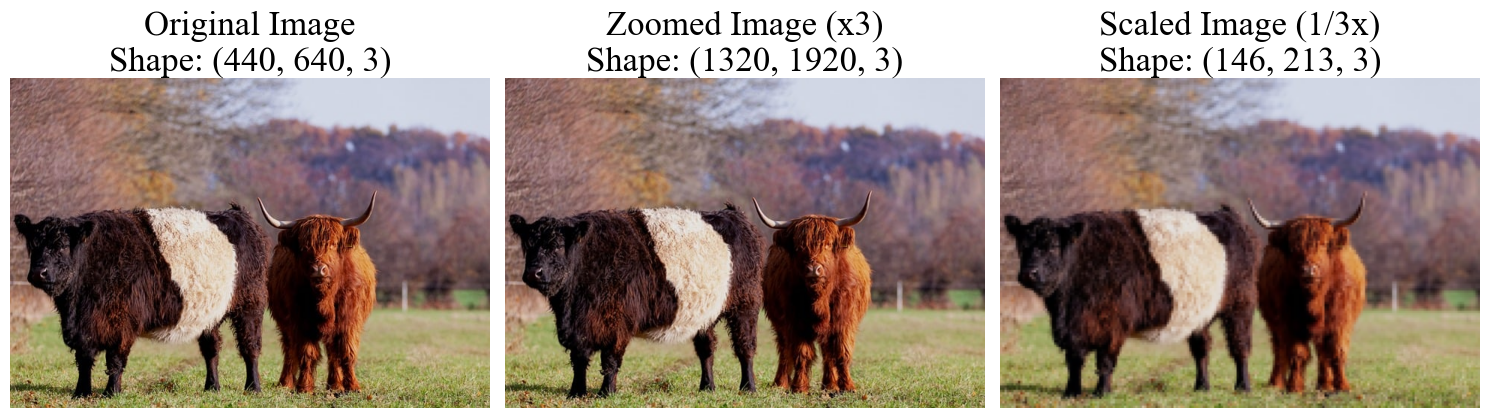

In [2]:
# ====== 1. Read and Load Image ======
# Load image path and read image
image_path = 'DATA/wildlife-9653797_640.jpg'
image = cv2.imread(image_path)

# Convert from BGR (OpenCV default) to RGB color space for correct display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get the original image dimensions (height and width)
height, width = image_rgb.shape[:2]

# ====== 2. Define Scaling Factors ======
# Set scale factors for zooming in and scaling down
scale_up_factor = 3.0         # Triple the size
scale_down_factor = 1 / 3.0   # Reduce to one-third

# Calculate new dimensions for zoomed and scaled images
zoomed_size = (int(width * scale_up_factor), int(height * scale_up_factor))
scaled_size = (int(width * scale_down_factor), int(height * scale_down_factor))

# ====== 3. Zoom In Image ======
# Use cubic interpolation (INTER_CUBIC): smoother results when zooming in,
# calculates based on 16 neighboring pixels (4x4), high quality but slower
zoomed_image = cv2.resize(
    image_rgb,
    zoomed_size,
    interpolation=cv2.INTER_CUBIC  # Best for zooming in
)

# ====== 4. Scale Down Image ======
# Use area interpolation (INTER_AREA): best for shrinking images,
# uses pixel area relation for better detail preservation
scaled_image = cv2.resize(
    image_rgb,
    scaled_size,
    interpolation=cv2.INTER_AREA  # Best for scaling down
)

# ====== 5. Display Results ======
# Create a figure with three subplots side by side
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Define titles for each subplot with shape information
titles = [
    f'Original Image\nShape: {image_rgb.shape}',
    f'Zoomed Image (x3)\nShape: {zoomed_image.shape}',
    f'Scaled Image (1/3x)\nShape: {scaled_image.shape}'
]

# Store images in a list for easier plotting
images = [image_rgb, zoomed_image, scaled_image]

# Plot each image with its corresponding title
for ax, img, title in zip(axs, images, titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=25)
    ax.axis('off')  # Hide axes

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

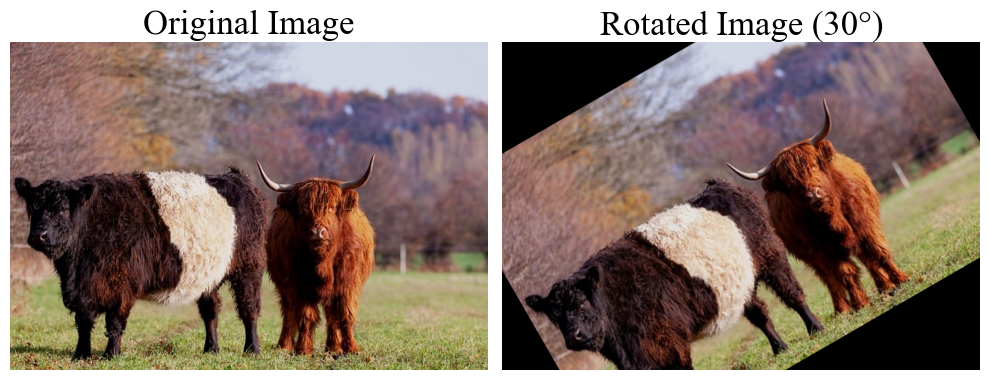

In [3]:
# ====== 1. Read and Convert Image to RGB ======
# OpenCV reads images in BGR format, need to convert to RGB for correct display with matplotlib
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# ====== 2. Define Image Center (Rotation Point) ======
# Calculate center point as the midpoint of width and height
center = (image_rgb.shape[1] // 2, image_rgb.shape[0] // 2)

# ====== 3. Set Rotation Parameters ======
angle = 30   # Rotation angle (in degrees), positive for counter-clockwise rotation
scale = 1.0  # Scale factor (1.0 means maintain original size)

# ====== 4. Create Rotation Matrix ======
# This matrix will be used to transform pixel coordinates
rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)

# ====== 5. Apply Image Rotation ======
# Use warpAffine to rotate the image using the rotation matrix
rotated_image = cv2.warpAffine(
    image_rgb,                  # Input image
    rotation_matrix,            # Rotation matrix
    (image_rgb.shape[1], image_rgb.shape[0])  # Output size (same as input)
)

# ====== 6. Display Original and Rotated Images ======
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Display original image
axs[0].imshow(image_rgb)
axs[0].set_title('Original Image', fontsize=25)
axs[0].axis('off')

# Display rotated image
axs[1].imshow(rotated_image)
axs[1].set_title('Rotated Image (30°)', fontsize=25)
axs[1].axis('off')

# Adjust spacing between subplots
plt.tight_layout()
plt.show()

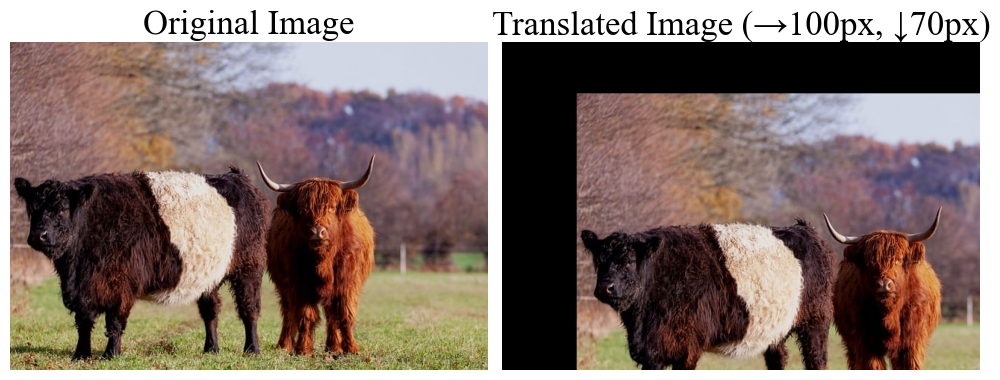

In [4]:
# ====== 1. Read and Convert Image to RGB ======
# Load and convert image to RGB color space for correct display
img = cv2.imread(image_path)
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ====== 2. Get Original Image Dimensions ======
# Get width and height for defining the output image frame after translation
height, width = image_rgb.shape[:2]

# ====== 3. Define Translation Parameters ======
tx, ty = 100, 70  # Move image 100 pixels right and 70 pixels down

# ====== 4. Create Translation Matrix ======
# This is an affine transformation matrix for translation:
# [[1, 0, tx],
#  [0, 1, ty]]
translation_matrix = np.array([
    [1, 0, tx],
    [0, 1, ty]
], dtype=np.float32)

# ====== 5. Apply Image Translation ======
# Use warpAffine to move each pixel to its new position using the translation matrix
translated_image = cv2.warpAffine(
    image_rgb,                 # Input image
    translation_matrix,        # Translation matrix
    (width, height)           # Output image size (same as input)
)

# ====== 6. Display Original and Translated Images ======
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Display original image
axs[0].imshow(image_rgb)
axs[0].set_title('Original Image', fontsize=25, fontname='serif')
axs[0].axis('off')

# Display translated image
axs[1].imshow(translated_image)
axs[1].set_title('Translated Image (→100px, ↓70px)', fontsize=25, fontname='serif')
axs[1].axis('off')

# Adjust layout spacing
plt.tight_layout()
plt.show()

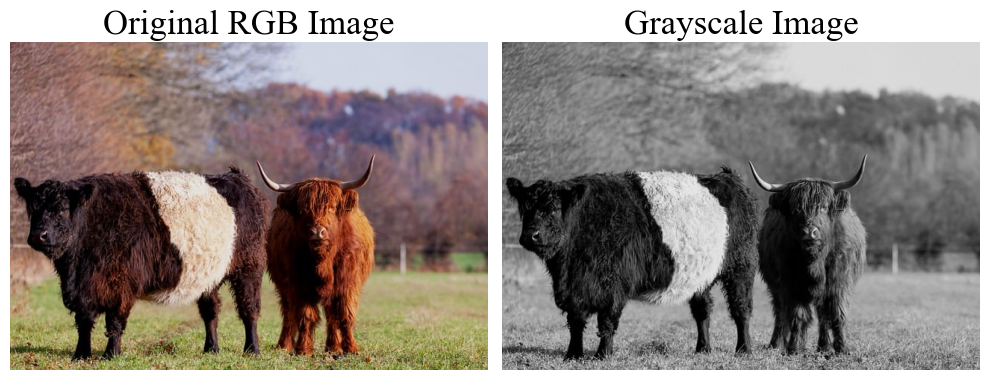

In [5]:
# ====== 1. Read Image in Grayscale ======
# cv2.IMREAD_GRAYSCALE helps read and convert image to 8-bit grayscale
image_bgr = cv2.imread(image_path)

# ====== 2. Convert to RGB for Correct Color Display ======
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# ====== 3. Read Image in Grayscale Mode ======
image_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# ====== 4. Display Original and Grayscale Images Side by Side ======
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Column 1: Original RGB Image
axs[0].imshow(image_rgb)
axs[0].set_title('Original RGB Image', fontsize=25)
axs[0].axis('off')

# Column 2: Grayscale Image
axs[1].imshow(image_gray, cmap='gray')
axs[1].set_title('Grayscale Image', fontsize=25)
axs[1].axis('off')

# Adjust layout spacing
plt.tight_layout()
plt.show()

In [6]:
# Import required libraries
import numpy as np    # For numerical operations
import cv2           # For image processing operations

In [7]:
# Define image path and load the image
image_path = 'DATA/wildlife-9653797_640.jpg'
image = cv2.imread(image_path)

# Convert from BGR to RGB color space for correct color display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

Image dimensions (height, width, channels): (440, 640, 3)
Successfully saved RGB image data to text file.
Successfully saved RGB image data to text file.


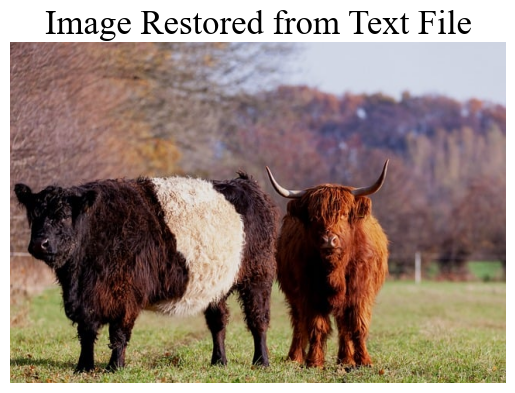

In [8]:
# Import required libraries
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ====== 1. Read and Convert Image to RGB Format ======
# Define path to the image
image_path = 'DATA/wildlife-9653797_640.jpg'

# Read image using OpenCV (image will be read in BGR - Blue Green Red format)
image = cv2.imread(image_path)
# Convert image from BGR to RGB as matplotlib and other tools typically use RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Print the image dimensions after conversion
# image_rgb.shape returns (height, width, number of channels)
print("Image dimensions (height, width, channels):", image_rgb.shape)

# ====== 2. Convert Image from 3D to 2D Array for File Storage ======
# Reshape image from (height, width, 3) => (height*width, 3)
# Each row corresponds to one pixel, containing 3 values: R, G, B
image_2d = image_rgb.reshape(-1, 3)

# ====== 3. Save Image Data to Text File ======
# Save 2D array as a .txt file
# - '%d' formats each value as an integer
# - delimiter=',' separates values with commas
np.savetxt('DATA/image_rgb_values.txt', image_2d, fmt='%d', delimiter=',')

print("Successfully saved RGB image data to text file.")

# ====== 4. (Optional) Read Back and Verify Image ======

# Read data from .txt file
# - delimiter=',' matches the save format
# - dtype=np.uint8 restores correct image data type
data = np.loadtxt('DATA/image_rgb_values.txt', delimiter=',', dtype=np.uint8)

# Convert 2D array back to 3D array with original image dimensions
image_restored = data.reshape(image_rgb.shape)

# Display restored image for verification
plt.imshow(image_restored)
plt.axis('off')  # Hide axes
plt.title('Image Restored from Text File', fontsize=25)
plt.show()